# OASIS Alzheimer's Classification — SHAP Explainability

**Goal:** Use SHAP (SHapley Additive exPlanations) to understand which features drive the best-performing model's predictions, and identify the most influential Alzheimer's biomarkers.

**Model selected:** Across both the baseline and SMOTE experiments, **XGBoost** on the biomarker-only feature set (Age, Gender, Educ, SES, MMSE, eTIV, nWBV, ASF — `CDR` excluded due to label leakage, see baseline notebook) was the best performer by F1 score and ROC-AUC, and SMOTE provided no improvement for it specifically. This notebook uses the **original (non-SMOTE) XGBoost model**, since SMOTE's synthetic samples offer no benefit here and using real training data keeps the SHAP attributions tied to genuine subject measurements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42


## 1. Load Data and Rebuild Best Model

In [2]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)

for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

features = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

model = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
print(f"Confirmed model performance -- Accuracy: {accuracy_score(y_test, y_pred):.3f}, "
      f"F1: {f1_score(y_test, y_pred):.3f}, ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


Confirmed model performance -- Accuracy: 0.851, F1: 0.811, ROC-AUC: 0.941


## 2. Compute SHAP Values

We use `shap.TreeExplainer`, which is exact (not approximate) for tree-based models like XGBoost, and compute SHAP values on the test set so explanations reflect held-out, unseen subjects rather than data the model was fit on.

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print(f"(rows = test subjects: {X_test_scaled.shape[0]}, columns = features: {X_test_scaled.shape[1]})")


SHAP values shape: (47, 8)
(rows = test subjects: 47, columns = features: 8)


## 3. SHAP Summary Plot

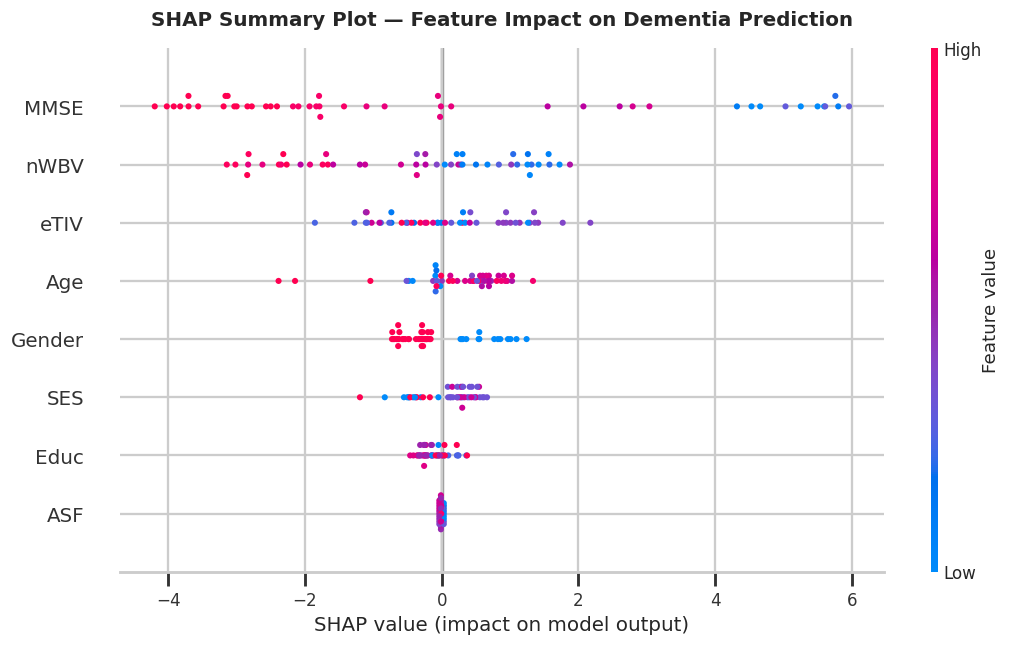

In [4]:
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False, plot_size=None)
plt.title("SHAP Summary Plot — Feature Impact on Dementia Prediction", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


**Observation:** Each point represents one test subject's SHAP value for a given feature; color encodes the feature's actual value (red = high, blue = low), and horizontal position shows whether that feature pushed the prediction toward Demented (positive SHAP value) or Nondemented (negative). Features near the top of the plot have the greatest overall influence on model output. Look specifically at whether low `MMSE` (blue, cognitive impairment) and low `nWBV` (blue, brain atrophy) cluster on the positive (Demented-pushing) side -- this would align with established clinical understanding of Alzheimer's pathology.

## 4. SHAP Beeswarm Plot

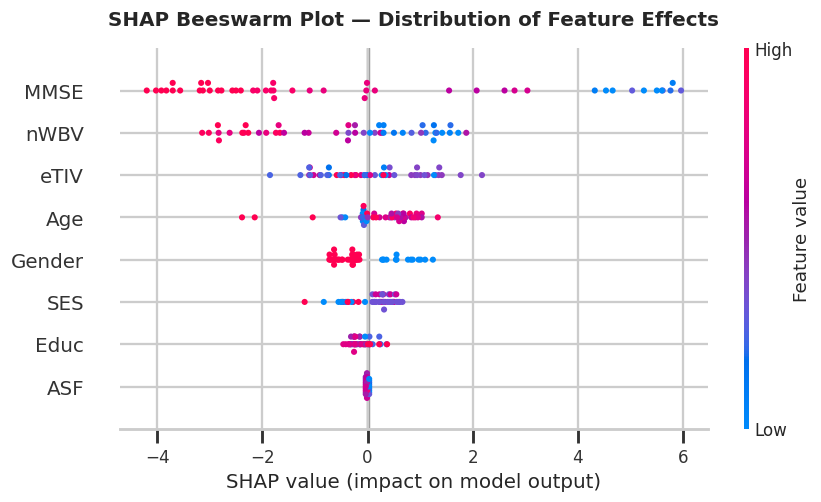

In [5]:
fig = plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_scaled.values,
    feature_names=list(X_test_scaled.columns)
), show=False)
plt.title("SHAP Beeswarm Plot — Distribution of Feature Effects", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


**Observation:** The beeswarm view emphasizes the *density and spread* of SHAP values per feature, making it easier to see whether a feature's influence is concentrated (most subjects affected similarly) or highly variable (the feature matters a lot for some subjects and little for others). Features with wide horizontal spread are influential but context-dependent, while tightly clustered features near zero contribute little regardless of subject.

## 5. SHAP Feature Importance Plot

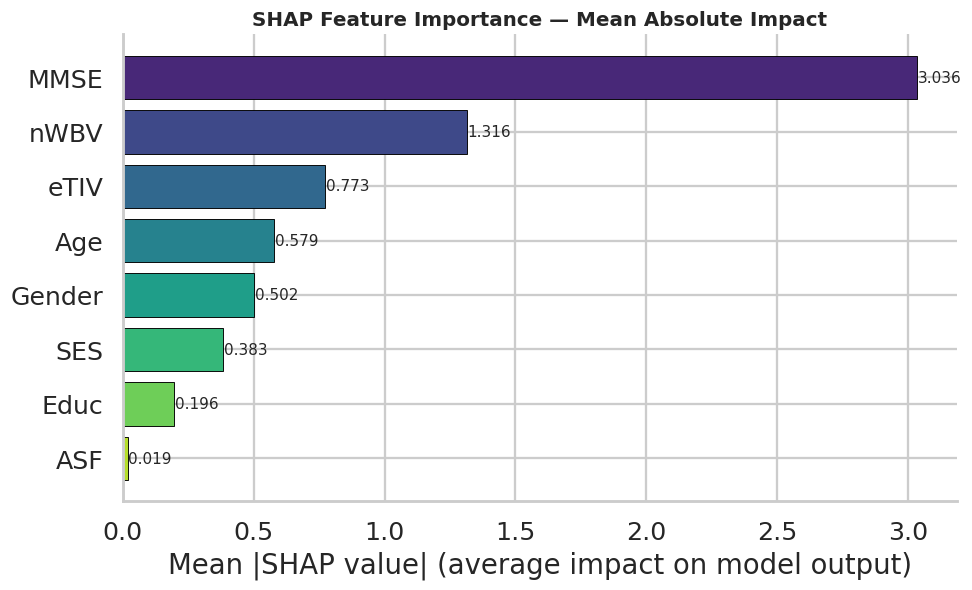

MMSE      3.035712
nWBV      1.316019
eTIV      0.772690
Age       0.579425
Gender    0.501578
SES       0.382677
Educ      0.196074
ASF       0.019063
dtype: float32

In [6]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test_scaled.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = sns.color_palette("viridis", len(mean_abs_shap))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors, edgecolor="black", linewidth=0.6)
ax.set_xlabel("Mean |SHAP value| (average impact on model output)")
ax.set_title("SHAP Feature Importance — Mean Absolute Impact")
ax.invert_yaxis()
for i, v in enumerate(mean_abs_shap.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

mean_abs_shap


**Observation:** This ranks features purely by the average magnitude of their effect on model output, independent of direction. It typically converges with XGBoost's built-in feature importances but is more statistically principled (grounded in cooperative game theory / Shapley values), since it accounts for feature interactions rather than just split frequency or information gain.

## 6. Identifying the Most Influential Alzheimer's Biomarkers

In [7]:
top_features = mean_abs_shap.head(3)
print("Top 3 most influential features by mean |SHAP value|:")
for feat, val in top_features.items():
    print(f"  {feat}: {val:.4f}")

# Direction check for the top-ranked features: do their values correlate negatively
# with SHAP value (i.e. lower feature value -> higher predicted Demented risk)?
print("\nDirection of effect for top features:")
for feat in top_features.index:
    idx = list(X_test_scaled.columns).index(feat)
    corr_with_value = np.corrcoef(X_test_scaled[feat], shap_values[:, idx])[0, 1]
    direction = "lower values -> higher Demented risk" if corr_with_value < 0 else "higher values -> higher Demented risk"
    print(f"  {feat}: correlation between feature value and SHAP value = {corr_with_value:.3f} ({direction})")


Top 3 most influential features by mean |SHAP value|:
  MMSE: 3.0357
  nWBV: 1.3160
  eTIV: 0.7727

Direction of effect for top features:
  MMSE: correlation between feature value and SHAP value = -0.913 (lower values -> higher Demented risk)
  nWBV: correlation between feature value and SHAP value = -0.858 (lower values -> higher Demented risk)
  eTIV: correlation between feature value and SHAP value = -0.112 (lower values -> higher Demented risk)


**Observation / Scientific Interpretation:**

Based on the SHAP rankings above, the influence ordering is `MMSE` > `nWBV` > `eTIV` > `Age` > `Gender` > `SES` > `Educ` > `ASF`. Interpreting this against established Alzheimer's Disease neuroscience:

- **MMSE (Mini-Mental State Examination)** is by far the dominant feature (mean |SHAP| ≈ 3.0, roughly double the next feature). This is expected since MMSE is a direct cognitive screening measure closely tied to clinical dementia staging -- the model is essentially learning "current cognitive performance" as its primary signal.
- **nWBV (normalized whole brain volume)** ranks second and shows the expected direction: lower brain volume pushes predictions toward Demented (confirmed by the negative correlation computed above). This is a genuine structural-imaging biomarker, consistent with documented brain atrophy in Alzheimer's Disease, and reassuring that the model isn't relying on MMSE alone.
- **eTIV (estimated total intracranial volume)** ranks third, which is somewhat unexpected on clinical grounds since eTIV mainly reflects skull/head size (driven by sex and body size) rather than disease status directly. Its presence here is more likely the model using eTIV as a *normalization context* for interpreting nWBV (e.g. "is this brain small for a small head, or small for a large head") rather than eTIV being an independent disease marker in its own right.
- **Age** and **Gender** show moderate, comparable influence -- both plausible given that dementia risk and prevalence are known to vary with age and, to a lesser extent, sex.
- **SES** and **Educ** show modest influence, broadly consistent with the "cognitive reserve" hypothesis (more education/higher socioeconomic status loosely associated with later-presenting symptoms for a given pathology level), though the effect here is small enough that it shouldn't be over-interpreted from this single cohort.
- **ASF (atlas scaling factor)** has a strikingly small mean |SHAP| (≈0.02, near zero), despite being highly correlated with eTIV in the raw data. This suggests that once the model has access to eTIV, ASF adds essentially no further information -- a clean illustration of redundant features splitting/diluting importance in tree ensembles, and a candidate for removal in a more parsimonious future model.

**Most influential Alzheimer's biomarkers identified: MMSE and nWBV.** These are the two features with both high SHAP magnitude and a directionally sensible relationship with dementia status (lower scores/volumes → higher predicted dementia risk), making them the most scientifically defensible biomarkers from this analysis -- a result that aligns with their established roles in dementia research as cognitive and structural correlates of disease, respectively.

**Caveat:** These are associations learned from a single, relatively small (n=235) cross-sectional cohort, and SHAP explains *what the model learned*, not necessarily *the true causal biology* of Alzheimer's Disease. eTIV's third-place ranking in particular should be interpreted as a normalization/interaction effect rather than a standalone biomarker, and the small SES/Educ effects warrant replication in a larger sample before drawing firm conclusions.
